# Discrete Manifold Navigation

HAM does not require an analytic manifold. Real geometry often arrives as a triangle mesh — a LiDAR scan, a CAD model, an FEM surface. The `TriangularMesh` manifold plugs into the same Finsler metrics and the same AVBD solver, so Zermelo navigation runs directly over the facets.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. A discrete environment

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from ham.geometry import Euclidean, Randers, TriangularMesh
from ham.solvers import AVBDSolver
from ham.vis import generate_icosphere
from ham.vis.style import (use_ham_style, PALETTE, plotly_layout, plotly_mesh,
                           plotly_path, plotly_cones)

pio.renderers.default = "plotly_mimetype"
use_ham_style()
key = jax.random.PRNGKey(0)

verts, faces = generate_icosphere(radius=1.0, subdivisions=3)
mesh = TriangularMesh(verts, faces)
print(f"mesh: {verts.shape[0]} vertices, {faces.shape[0]} faces")

mesh: 642 vertices, 1280 faces


## 2. A wind over the mesh

The current $W(x)$ is a global function of position; the `Randers` metric projects it onto each face's
tangent plane, so the discrete geodesic stays on the surface while feeling the wind. We use the same
azimuthal trade wind as the continuous demo.

In [2]:
def w_net(x):
    return 0.8 * jnp.array([-x[1], x[0], 0.0])


def h_net(x):
    return jnp.eye(3)


discrete_randers = Randers(mesh, h_net, w_net)
discrete_eucl = Euclidean(mesh)

## 3. Discrete trajectory optimization

The same `AVBDSolver` relaxes the path over the mesh topology. We compare the wind-blind shortest path
(`Euclidean`) with the wind-aware `Randers` route.

In [3]:
start = jnp.array([1.0, 0.0, 0.0])
end = jnp.array([0.0, 0.0, 1.0])
solver = AVBDSolver(step_size=0.05, beta=10.0, iterations=300)

traj_eucl = solver.solve(discrete_eucl, start, end, n_steps=40, key=key)
traj_rand = solver.solve(discrete_randers, start, end, n_steps=40, key=key)

sep = float(jnp.max(jnp.linalg.norm(traj_eucl.xs - traj_rand.xs, axis=1)))
print(f"max separation between shortest and wind-optimal route: {sep:.3f}")

max separation between shortest and wind-optimal route: 0.063


## 4. The mesh, the field, and the routes

We render the faceted surface, draw the wind over the mesh (cone size follows the wind speed), and
overlay both routes. Rotate the figure to see the wind-aware route peel away from the shortest path
along the facets.

In [4]:
verts_np = np.array(verts)
W = np.array(jax.vmap(lambda p: mesh.to_tangent(p, w_net(p)))(jnp.array(verts)))
keep = np.linalg.norm(W, axis=1) > 0.06

fig = go.Figure()
fig.add_trace(plotly_mesh(verts_np, np.array(faces), opacity=0.5))
fig.add_trace(plotly_cones(verts_np[keep], W[keep], name="wind", sizeref=0.3,
                           showscale=True, colorbar_title="wind speed"))
fig.add_trace(plotly_path(traj_eucl.xs, color=PALETTE["muted"], name="shortest path",
                          width=6, dash="dash"))
fig.add_trace(plotly_path(traj_rand.xs, color=PALETTE["accent"], name="wind-optimal (Randers)",
                          width=8))
plotly_layout(fig, "Zermelo navigation on a triangle mesh")
fig.show()

## 5. Staying on the surface

Every path vertex is retracted onto the mesh, so the route never penetrates the interior. We confirm the
path radius stays at 1 (the icosphere radius) within discretization error.

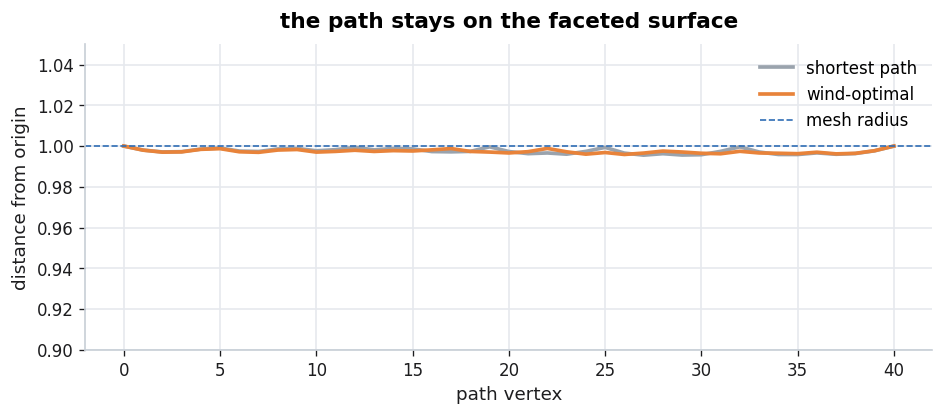

max radial deviation from the surface: 0.0045


In [5]:
r_eucl = np.linalg.norm(np.array(traj_eucl.xs), axis=1)
r_rand = np.linalg.norm(np.array(traj_rand.xs), axis=1)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(r_eucl, color=PALETTE["muted"], label="shortest path")
ax.plot(r_rand, color=PALETTE["accent"], label="wind-optimal")
ax.axhline(1.0, color=PALETTE["primary"], ls="--", lw=1, label="mesh radius")
ax.set_ylim(0.9, 1.05); ax.set_xlabel("path vertex"); ax.set_ylabel("distance from origin")
ax.set_title("the path stays on the faceted surface"); ax.legend()
plt.tight_layout(); plt.show()
print(f"max radial deviation from the surface: {np.max(np.abs(np.concatenate([r_eucl, r_rand]) - 1)):.4f}")

## 6. Notes

* A `TriangularMesh` is a first-class `Manifold`: the same Randers metric and AVBD solver work on it
  with no special-casing, so methods developed on analytic surfaces transfer to scanned or CAD geometry.
* Visualizing the wind everywhere (not on a single ring) shows how the Randers route deflects from the
  shortest path across the mesh.
* Per-vertex retraction keeps the path on the surface — the discrete form of the manifold constraint.